In [13]:
import sys
!{sys.executable} -m pip install deap numpy matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: /Users/vikasshukla/.pyenv/versions/3.11.6/bin/python -m pip install --upgrade pip


In [14]:
import numpy as np
import matplotlib.pyplot as plt

from deap import base, benchmarks, cma, creator, tools

In [15]:
# Function to create toolbox

def create_toolbox(strategy):

    if "FitnessMin" not in creator.__dict__:
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()

    toolbox.register("evaluate", benchmarks.rastrigin)

    np.random.seed(7)

    toolbox.register("generate", strategy.generate, creator.Individual)
    toolbox.register("update", strategy.update)

    return toolbox

In [17]:
num_individuals = 10
num_generations = 125

In [18]:
strategy = cma.Strategy(
    centroid=[5.0] * num_individuals,
    sigma=5.0,
    lambda_=20 * num_individuals
)

In [19]:
toolbox = create_toolbox(strategy)

In [20]:
hall_of_fame = tools.HallOfFame(1)

In [21]:
stats = tools.Statistics(lambda x: x.fitness.values)

stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

In [22]:
logbook = tools.Logbook()
logbook.header = "gen", "evals", "std", "min", "avg", "max"

In [23]:
sigma = np.ndarray((num_generations, 1))
axis_ratio = np.ndarray((num_generations, 1))
diagD = np.ndarray((num_generations, num_individuals))
fbest = np.ndarray((num_generations, 1))
best = np.ndarray((num_generations, num_individuals))
std = np.ndarray((num_generations, num_individuals))

In [24]:
for gen in range(num_generations):

    # Generate a new population
    population = toolbox.generate()

    # Evaluate individuals
    fitnesses = toolbox.map(toolbox.evaluate, population)

    for individual, fitness in zip(population, fitnesses):
        individual.fitness.values = fitness

    # Update strategy with evaluated individuals
    toolbox.update(population)

    # Update hall of fame and statistics
    hall_of_fame.update(population)

    record = stats.compile(population)

    logbook.record(
        evals=len(population),
        gen=gen,
        **record
    )

    print(logbook.stream)

    # Save data for plotting
    sigma[gen] = strategy.sigma
    axis_ratio[gen] = max(strategy.diagD) ** 2 / min(strategy.diagD) ** 2
    diagD[gen, :num_individuals] = strategy.diagD ** 2
    fbest[gen] = hall_of_fame[0].fitness.values
    best[gen, :num_individuals] = hall_of_fame[0]
    std[gen, :num_individuals] = np.std(population, axis=0)

gen	evals	std   	min    	avg    	max    
0  	200  	188.36	217.082	576.281	1199.71
1  	200  	267.771	177.951	664.621	1886.26
2  	200  	278.323	241.077	697.146	1801.67
3  	200  	218.546	137.702	513.883	1307.41
4  	200  	131.992	140.886	374.041	739.372
5  	200  	84.5236	113.862	291.389	625.977
6  	200  	66.4526	126.375	243.34 	469.926
7  	200  	49.7153	82.8412	197.511	348.043
8  	200  	38.3504	73.0274	167.743	309.409
9  	200  	37.4221	76.7296	162.881	337.876
10 	200  	31.584 	90.0571	151.457	250.642
11 	200  	28.7502	60.9416	137.673	255.886
12 	200  	30.5608	58.3516	136.254	242.471
13 	200  	28.2293	61.0749	132.133	200.212
14 	200  	24.8966	73.6083	128.44 	201.353
15 	200  	24.0441	44.6969	121.76 	184.873
16 	200  	23.8312	66.5502	117.786	183.772
17 	200  	22.3703	49.7996	118.032	173.369
18 	200  	21.2466	50.2553	111.336	164.842
19 	200  	23.693 	29.7588	110.346	167.159
20 	200  	23.1049	37.4303	108.531	166.706
21 	200  	23.6721	52.7345	112.505	158.215
22 	200  	21.6273	46.0387	108.519	15

In [25]:
x = list(range(0, strategy.lambda_ * num_generations, strategy.lambda_))

avg, max_, min_ = logbook.select("avg", "max", "min")

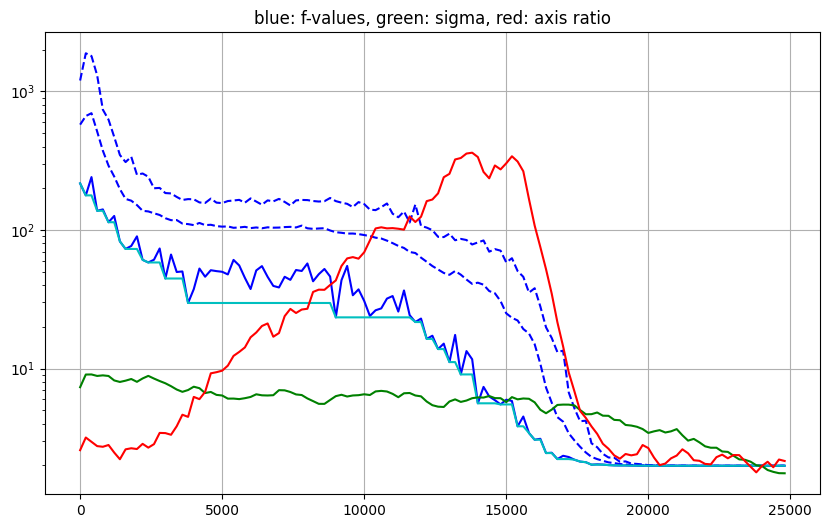

In [26]:
plt.figure(figsize=(10, 6))

plt.semilogy(x, avg, "--b")
plt.semilogy(x, max_, "--b")
plt.semilogy(x, min_, "-b")
plt.semilogy(x, fbest, "-c")
plt.semilogy(x, sigma, "-g")
plt.semilogy(x, axis_ratio, "-r")

plt.grid(True)
plt.title("blue: f-values, green: sigma, red: axis ratio")
plt.show()

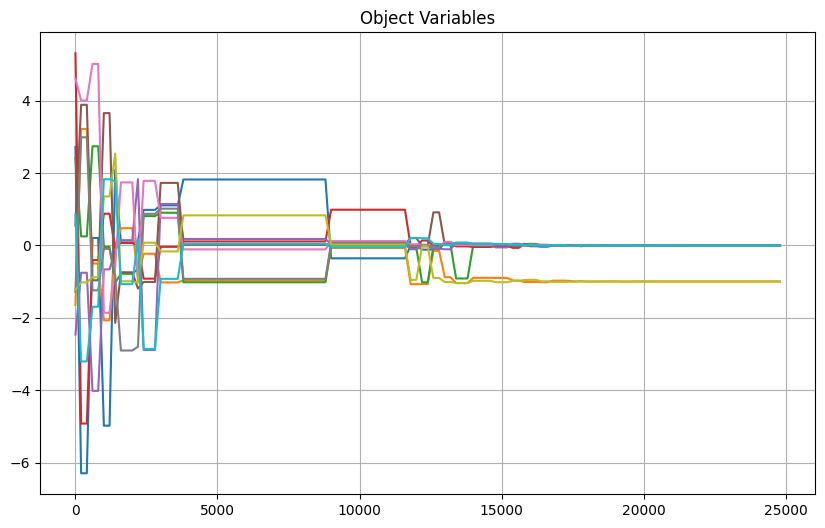

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(x, best)

plt.grid(True)
plt.title("Object Variables")
plt.show()

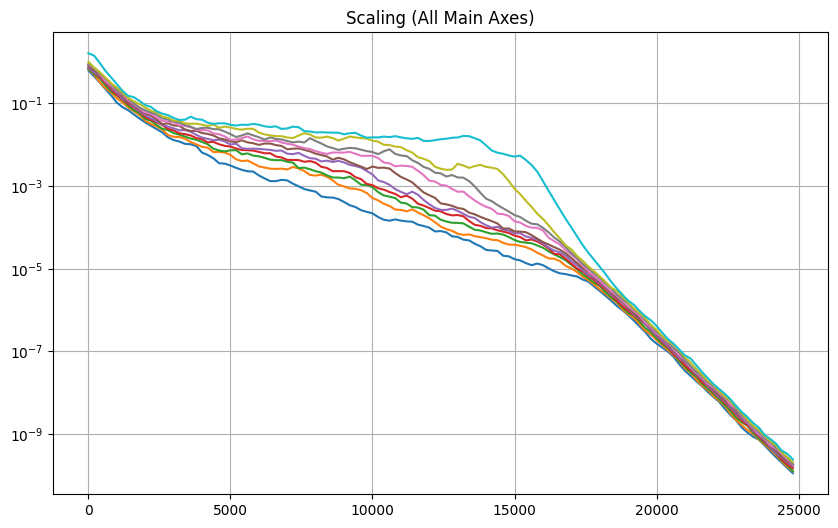

In [28]:
plt.figure(figsize=(10, 6))

plt.semilogy(x, diagD)

plt.grid(True)
plt.title("Scaling (All Main Axes)")
plt.show()

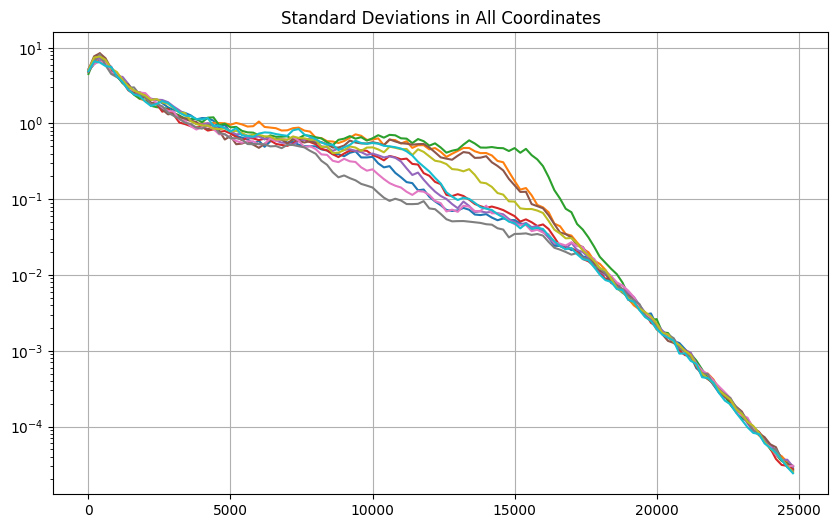

In [29]:
plt.figure(figsize=(10, 6))

plt.semilogy(x, std)

plt.grid(True)
plt.title("Standard Deviations in All Coordinates")
plt.show()